In [4]:
import pandas as pd
import numpy as np
import json

In [ ]:
MODELS = [
    "models_saved/model_w(0,0,0,1).json",
    "models_saved/model_w(0,0,1,0).json",
    "models_saved/model_w(0,1,0,0).json",
    "models_saved/model_w(1,0,0,0).json",
    "models_saved/Qwen.json",
    "models_saved/model_w(0.60,0.15,0.15,0.10).json",
    "models_saved/model_w(0.20,0.50,0.20,0.10).json",
    "models_saved/model_w(0.15,0.20,0.50,0.15).json",
    "models_saved/model_w(0.10,0.20,0.20,0.50).json",
    "models_saved/model_w(0.35,0.30,0.15,0.25).json"
]
ablatiobn_names = [
    "Standard DPO",
    "Ra-Only HiPO",
    "Mt-Only HiPO",
    "Rq-Only HiPO",
    "Base Qwen2.5",
    "Seq-0",
    "Seq-1",
    "Seq-2",
    "Seq-3",
    "Seq-4"
]

In [77]:
imp_columns = [
    "Logical Flow",
    "Structural Organization",
    "Consistency",
    # "Factual Correctness",
    "Domain Knowledge Application",
    "Reasoning Validity",
    # "Final Answer Correctness",
    "Strategy Usefulness",
    "Progress Toward Solution",
    "Partial Success Recognition",
    "Error Robustness",
    # "verbosity",
    # "final_comment"
]

In [78]:
final_df = pd.DataFrame()

for model in MODELS:
    with open(model, "r") as f:
        data = f.read()
    data = pd.read_json(data)
    data['bench'] = data['bench'].fillna("Math500")
    print(ablatiobn_names[MODELS.index(model)])
    print(data[['Final Answer Correctness', 'Factual Correctness']].mean()*np.array([10,10]))
    print(data.groupby('bench')[['Final Answer Correctness', 'Factual Correctness']].mean()*np.array([10,10]))
    print("")
    plotting_data = data[imp_columns].mean().to_frame().T
    final_df = pd.concat([final_df, plotting_data], ignore_index=True)


Standard DPO
Final Answer Correctness    53.000000
Factual Correctness         77.166667
dtype: float64
         Final Answer Correctness  Factual Correctness
bench                                                 
GSM8K                   57.333333            86.666667
Math500                 48.666667            67.666667

Ra-Only HiPO
Final Answer Correctness    58.166667
Factual Correctness         83.666667
dtype: float64
         Final Answer Correctness  Factual Correctness
bench                                                 
GSM8K                   63.333333            90.333333
Math500                 53.000000            77.000000

Mt-Only HiPO
Final Answer Correctness    75.333333
Factual Correctness         89.750000
dtype: float64
         Final Answer Correctness  Factual Correctness
bench                                                 
GSM8K                   80.000000                 94.0
Math500                 70.666667                 85.5

Rq-Only HiPO
Final Answer

C:\Users\kachr\AppData\Local\Temp\ipykernel_17660\2387145987.py:6: FutureWarning: Passing literal json to 'read_json' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  data = pd.read_json(data)
C:\Users\kachr\AppData\Local\Temp\ipykernel_17660\2387145987.py:6: FutureWarning: Passing literal json to 'read_json' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  data = pd.read_json(data)
C:\Users\kachr\AppData\Local\Temp\ipykernel_17660\2387145987.py:6: FutureWarning: Passing literal json to 'read_json' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  data = pd.read_json(data)
C:\Users\kachr\AppData\Local\Temp\ipykernel_17660\2387145987.py:6: FutureWarning: Passing literal json to 'read_json' is deprecated and will be removed in a future version. To read from a literal string, wrap

In [79]:
final_df

,Logical Flow,Structural Organization,Consistency,Domain Knowledge Application,Reasoning Validity,Strategy Usefulness,Progress Toward Solution,Partial Success Recognition,Error Robustness
0,7.983333,8.091667,8.283333,7.916667,7.550000,8.091667,7.891667,7.608333,7.358333
1,8.608333,8.783333,8.858333,8.516667,8.183333,8.658333,8.500000,8.266667,8.058333
2,9.016667,8.983333,9.083333,9.066667,8.766667,9.175000,9.025000,8.941667,8.716667
3,9.258333,9.258333,9.366667,9.266667,9.008333,9.325000,9.250000,8.983333,8.833333
4,8.850000,8.908333,8.916667,8.850000,8.533333,8.983333,8.883333,8.733333,8.416667
5,9.066667,9.141667,9.166667,8.966667,8.625000,9.016667,8.950000,8.750000,8.550000
6,9.266667,9.341667,9.350000,9.266667,8.941667,9.383333,9.250000,9.100000,8.916667
7,9.266667,9.341667,9.375000,9.166667,8.791667,9.275000,9.225000,8.983333,8.783333
8,9.258333,9.316667,9.416667,9.358333,8.983333,9.408333,9.266667,9.075000,8.866667
9,9.216667,9.266667,9.283333,9.333333,9.033333,9.408333,9.258333,9.116667,8.900000


In [50]:
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, RegularPolygon
from matplotlib.path import Path
from matplotlib.projections.polar import PolarAxes
from matplotlib.projections import register_projection
from matplotlib.spines import Spine
from matplotlib.transforms import Affine2D

def radar_factory(num_vars, frame='circle'):
    """Create a radar chart with `num_vars` axes.

    This function creates a RadarAxes projection and registers it.

    Parameters
    ----------
    num_vars : int
        Number of variables for radar chart.
    frame : {'circle' | 'polygon'}
        Shape of frame surrounding axes.

    """
    # calculate evenly-spaced axis angles
    theta = np.linspace(0, 2*np.pi, num_vars, endpoint=False)
    
    class RadarTransform(PolarAxes.PolarTransform):
        def transform_path_non_affine(self, path):
            # Paths with non-unit interpolation steps correspond to gridlines,
            # in which case we force interpolation (to defeat PolarTransform's
            # autoconversion to circular arcs).
            if path._interpolation_steps > 1:
                path = path.interpolated(num_vars)
            return Path(self.transform(path.vertices), path.codes)

    class RadarAxes(PolarAxes):

        name = 'radar'
        
        PolarTransform = RadarTransform

        def __init__(self, *args, **kwargs):
            super().__init__(*args, **kwargs)
            # rotate plot such that the first axis is at the top
            self.set_theta_zero_location('N')

        def fill(self, *args, closed=True, **kwargs):
            """Override fill so that line is closed by default"""
            return super().fill(closed=closed, *args, **kwargs)

        def plot(self, *args, **kwargs):
            """Override plot so that line is closed by default"""
            lines = super().plot(*args, **kwargs)
            for line in lines:
                self._close_line(line)

        def _close_line(self, line):
            x, y = line.get_data()
            # FIXME: markers at x[0], y[0] get doubled-up
            if x[0] != x[-1]:
                x = np.concatenate((x, [x[0]]))
                y = np.concatenate((y, [y[0]]))
                line.set_data(x, y)

        def set_varlabels(self, labels):
            self.set_thetagrids(np.degrees(theta), labels)

        def _gen_axes_patch(self):
            # The Axes patch must be centered at (0.5, 0.5) and of radius 0.5
            # in axes coordinates.
            if frame == 'circle':
                return Circle((0.5, 0.5), 0.5)
            elif frame == 'polygon':
                return RegularPolygon((0.5, 0.5), num_vars,
                                      radius=.5, edgecolor="k")
            else:
                raise ValueError("unknown value for 'frame': %s" % frame)

        def draw(self, renderer):
            """ Draw. If frame is polygon, make gridlines polygon-shaped """
            if frame == 'polygon':
                gridlines = self.yaxis.get_gridlines()
                for gl in gridlines:
                    gl.get_path()._interpolation_steps = num_vars
            super().draw(renderer)


        def _gen_axes_spines(self):
            if frame == 'circle':
                return super()._gen_axes_spines()
            elif frame == 'polygon':
                # spine_type must be 'left'/'right'/'top'/'bottom'/'circle'.
                spine = Spine(axes=self,
                              spine_type='circle',
                              path=Path.unit_regular_polygon(num_vars))
                # unit_regular_polygon gives a polygon of radius 1 centered at
                # (0, 0) but we want a polygon of radius 0.5 centered at (0.5,
                # 0.5) in axes coordinates.
                spine.set_transform(Affine2D().scale(.5).translate(.5, .5)
                                    + self.transAxes)


                return {'polar': spine}
            else:
                raise ValueError("unknown value for 'frame': %s" % frame)

    register_projection(RadarAxes)
    return theta


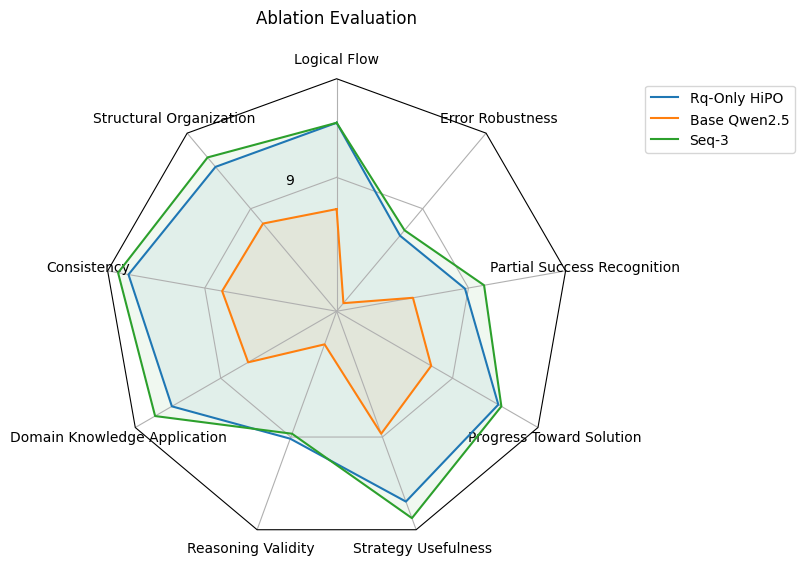

In [71]:

data = [final_df.columns.tolist(),
        ('Ablation Evaluation', final_df.values.tolist())]

N = len(data[0])
theta = radar_factory(N, frame='polygon')

spoke_labels = data.pop(0)
title, case_data = data[0]

fig, ax = plt.subplots(figsize=(6, 16), subplot_kw=dict(projection='radar'))
fig.subplots_adjust(top=0.85, bottom=0.05)

ax.set_rgrids([8,9,10])
ax.set_title(title, ha='center', pad=40)

for i,d in enumerate(case_data[:]):
    line = ax.plot(theta, d, label=ablatiobn_names[i])
    ax.fill(theta, d,  alpha=0.07)
ax.set_varlabels(spoke_labels)

ax.legend(loc='upper right', bbox_to_anchor=(1.5, 1))
plt.show()

In [40]:
plotting_data.values[:2]

array([[9.25833333, 9.25833333, 9.36666667, 9.26666667, 9.00833333,
        9.325     , 9.25      , 8.98333333, 8.83333333]])